In [3]:
import sys
import pandas as pd
import numpy as np

print(sys.executable)
print(sys.version)
print(pd.__version__)

ModuleNotFoundError: No module named 'pandas'

In [4]:
import sys
print(sys.executable)

C:\Users\wpqlc\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe


In [1]:
import sys
print(sys.executable)

c:\Users\wpqlc\OneDrive\바탕 화면\ESG 데이터\.venv\Scripts\python.exe


In [2]:
import pandas as pd
print(pd.__version__)

3.0.5


In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

print("라이브러리 로딩 완료")

라이브러리 로딩 완료


In [4]:
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.3f}".format)

In [5]:
df = pd.read_excel("data/2025_ESGrating.xlsx")

c:\Users\wpqlc\OneDrive\바탕 화면\ESG 데이터\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [6]:
df.head()

,NO,기업명,기업코드,ESG등급,환경,사회,지배구조,평가년도,ESG 등급조정,환경 등급조정,사회 등급조정,지배구조 등급조정
0,1091,AJ네트웍스,95570,B+,C,A,A,2025,NaN,NaN,NaN,NaN
1,1090,AK홀딩스,6840,A,A,A+,B+,2025,NaN,NaN,NaN,NaN
2,1089,BGF,27410,A,A,A+,B+,2025,NaN,NaN,NaN,NaN
3,1088,BGF리테일,282330,A+,A+,A+,A,2025,NaN,NaN,NaN,NaN
4,1087,BGF에코머티리얼즈,126600,B,B,B,B,2025,NaN,NaN,NaN,NaN


In [7]:
df.shape

(1091, 12)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1091 entries, 0 to 1090
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   NO         1091 non-null   int64  
 1   기업명        1091 non-null   str    
 2   기업코드       1091 non-null   int64  
 3   ESG등급      1091 non-null   str    
 4   환경         1091 non-null   str    
 5   사회         1091 non-null   str    
 6   지배구조       1091 non-null   str    
 7   평가년도       1091 non-null   int64  
 8   ESG 등급조정   24 non-null     str    
 9   환경 등급조정    0 non-null      float64
 10  사회 등급조정    32 non-null     str    
 11  지배구조 등급조정  24 non-null     str    
dtypes: float64(1), int64(3), str(8)
memory usage: 102.4 KB


In [9]:
df.describe()

,NO,기업코드,평가년도,환경 등급조정
count,1091.000,1091.000,1091.000,0.000
mean,546.000,107986.379,2025.000,NaN
std,315.089,180071.373,0.000,NaN
min,1.000,10.000,2025.000,NaN
25%,273.500,6770.000,2025.000,NaN
50%,546.000,32190.000,2025.000,NaN
75%,818.500,116515.000,2025.000,NaN
max,1091.000,888975.000,2025.000,NaN


In [10]:
df.isnull().sum()

NO              0
기업명             0
기업코드            0
ESG등급           0
환경              0
사회              0
지배구조            0
평가년도            0
ESG 등급조정     1067
환경 등급조정      1091
사회 등급조정      1059
지배구조 등급조정    1067
dtype: int64

In [11]:
df[df.duplicated()]

,NO,기업명,기업코드,ESG등급,환경,사회,지배구조,평가년도,ESG 등급조정,환경 등급조정,사회 등급조정,지배구조 등급조정


In [12]:
df[df['ESG등급'] == '등급없음']

,NO,기업명,기업코드,ESG등급,환경,사회,지배구조,평가년도,ESG 등급조정,환경 등급조정,사회 등급조정,지배구조 등급조정
6,1085,BNK캐피탈,801190,등급없음,등급없음,등급없음,B+,2025,NaN,NaN,NaN,NaN
7,1084,BNK투자증권,14876,등급없음,등급없음,등급없음,B+,2025,NaN,NaN,NaN,NaN
19,1072,DB생명보험,818158,등급없음,등급없음,등급없음,B,2025,NaN,NaN,NaN,NaN
78,1013,KB손해보험,2550,등급없음,등급없음,등급없음,A,2025,NaN,NaN,NaN,NaN
126,965,NH농협손해보험,839719,등급없음,등급없음,등급없음,A,2025,NaN,NaN,NaN,NaN
190,901,경남은행,192520,등급없음,등급없음,등급없음,B+,2025,NaN,NaN,NaN,NaN
210,881,광주은행,192530,등급없음,등급없음,등급없음,B+,2025,NaN,NaN,NaN,NaN
211,880,교보생명보험,811097,등급없음,등급없음,등급없음,B+,2025,NaN,NaN,NaN,NaN
215,876,국민은행,60000,등급없음,등급없음,등급없음,A,2025,NaN,NaN,NaN,NaN
259,832,농협금융지주,839683,등급없음,등급없음,등급없음,A,2025,NaN,NaN,NaN,NaN


In [13]:
(df['ESG등급'] == '등급없음').sum()

np.int64(66)

In [15]:
for col in ['ESG등급', '환경', '사회', '지배구조']:
    print(f"\n[{col}]")
    print(df[col].fillna('등급없음').value_counts())


[ESG등급]
ESG등급
D       311
C       240
A       213
B+      160
B        83
등급없음     66
A+       18
Name: count, dtype: int64

[환경]
환경
C       266
D       237
A       220
B+      178
B        83
등급없음     66
A+       41
Name: count, dtype: int64

[사회]
사회
D       245
A+      206
C       204
A       203
B+      112
등급없음     66
B        55
Name: count, dtype: int64

[지배구조]
지배구조
D       344
B+      223
C       198
B       162
A       155
A+        8
등급없음      1
Name: count, dtype: int64


In [16]:
cols = ['ESG등급', '환경', '사회', '지배구조']

grade_order = ['A+', 'A', 'B+', 'B', 'C', 'D', '등급없음']

grade_count = pd.DataFrame({
    col: df[col].fillna('등급없음').value_counts()
    for col in cols
}).reindex(grade_order).fillna(0).astype(int)

grade_count

,ESG등급,환경,사회,지배구조
A+,18,41,206,8
A,213,220,203,155
B+,160,178,112,223
B,83,83,55,162
C,240,266,204,198
D,311,237,245,344
등급없음,66,66,66,1


In [19]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Windows 한글 폰트
plt.rc('font', family='Malgun Gothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

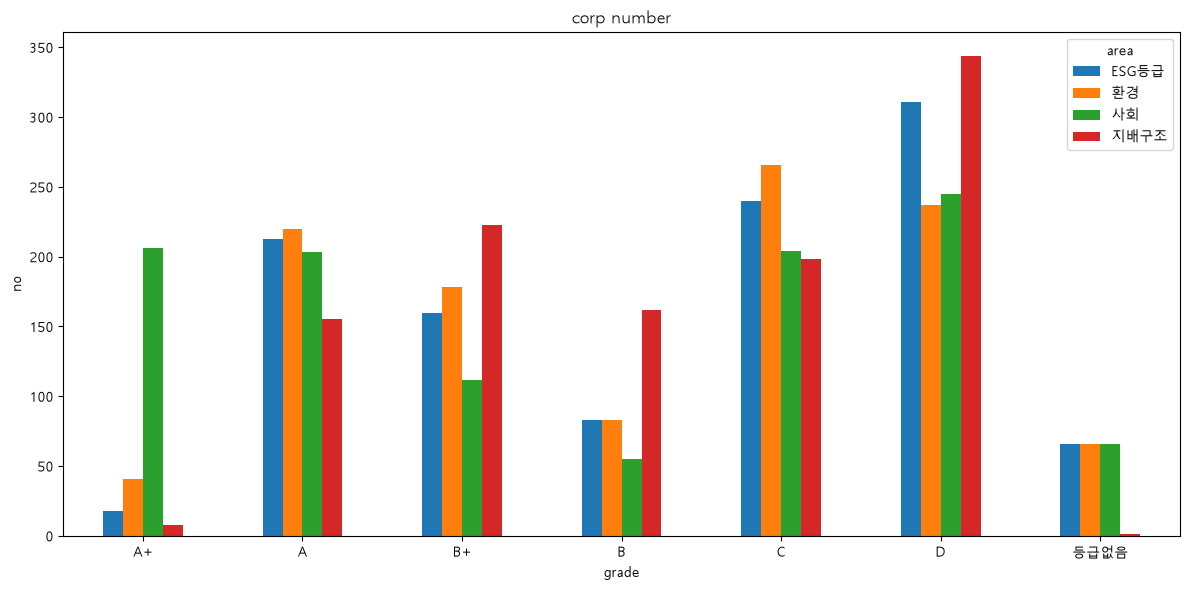

In [20]:
import matplotlib.pyplot as plt

grade_count.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('corp number')
plt.xlabel('grade')
plt.ylabel('no')
plt.xticks(rotation=0)
plt.legend(title='area')
plt.tight_layout()
plt.show()

In [22]:
grade_ratio = grade_count.div(grade_count.sum(axis=0), axis=1) * 100

grade_ratio.round(2)

,ESG등급,환경,사회,지배구조
A+,1.650,3.760,18.880,0.730
A,19.520,20.160,18.610,14.210
B+,14.670,16.320,10.270,20.440
B,7.610,7.610,5.040,14.850
C,22.000,24.380,18.700,18.150
D,28.510,21.720,22.460,31.530
등급없음,6.050,6.050,6.050,0.090


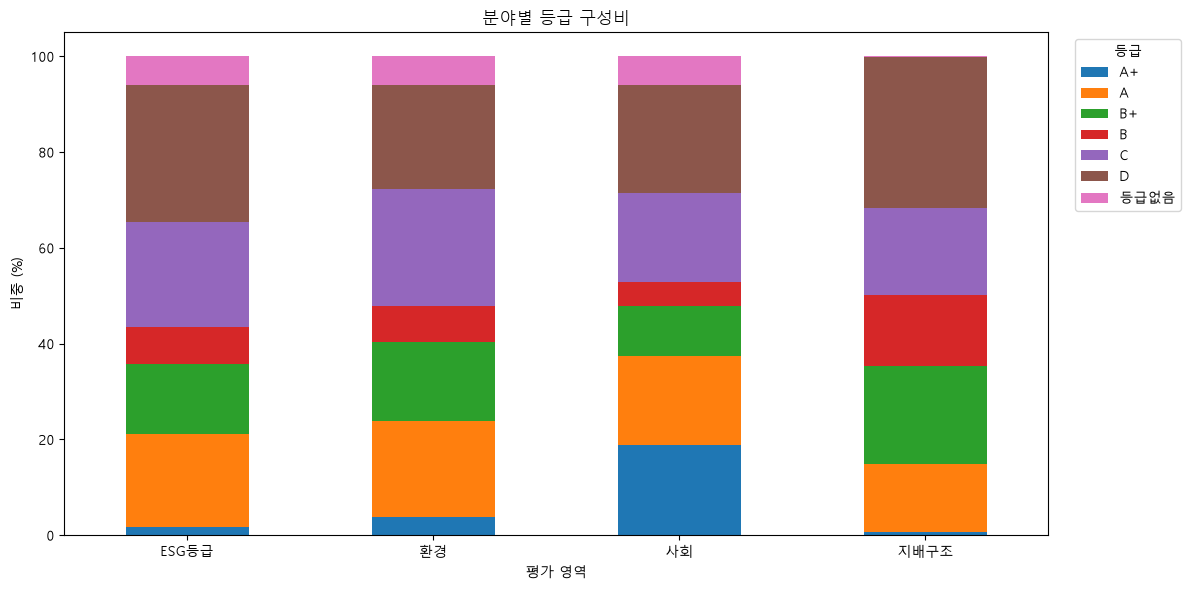

In [24]:
grade_ratio.T.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6)
)

plt.title('분야별 등급 구성비')
plt.xlabel('평가 영역')
plt.ylabel('비중 (%)')
plt.xticks(rotation=0)
plt.legend(title='등급', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


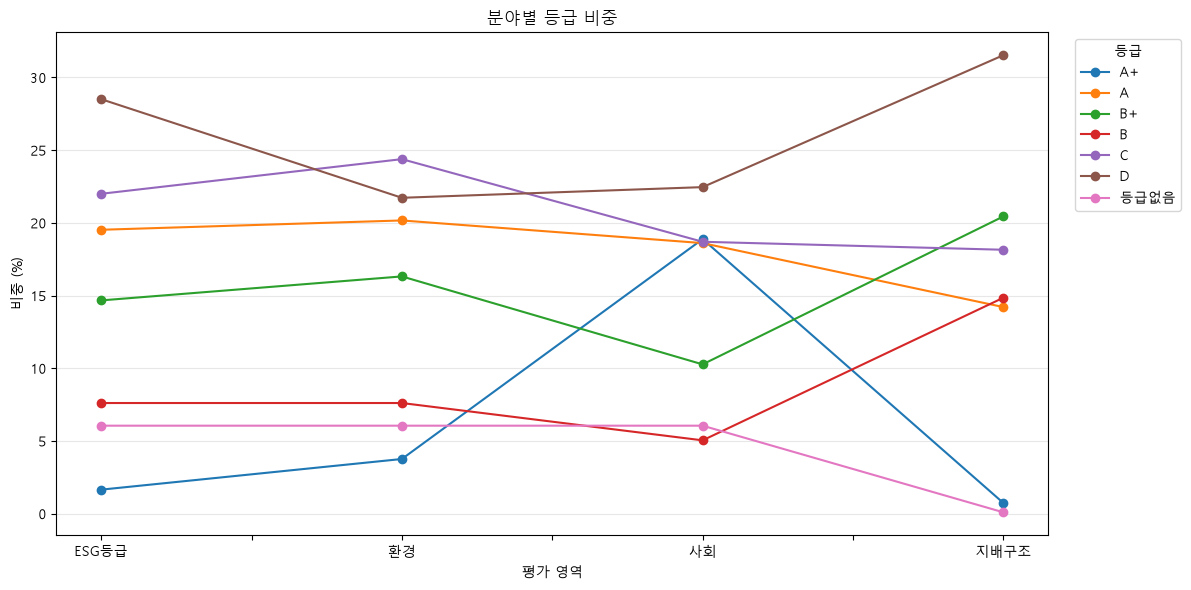

In [25]:
import matplotlib.pyplot as plt

grade_ratio.T.plot(
    kind='line',
    marker='o',
    figsize=(12, 6)
)

plt.title('분야별 등급 비중')
plt.xlabel('평가 영역')
plt.ylabel('비중 (%)')
plt.xticks(rotation=0)
plt.legend(title='등급', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

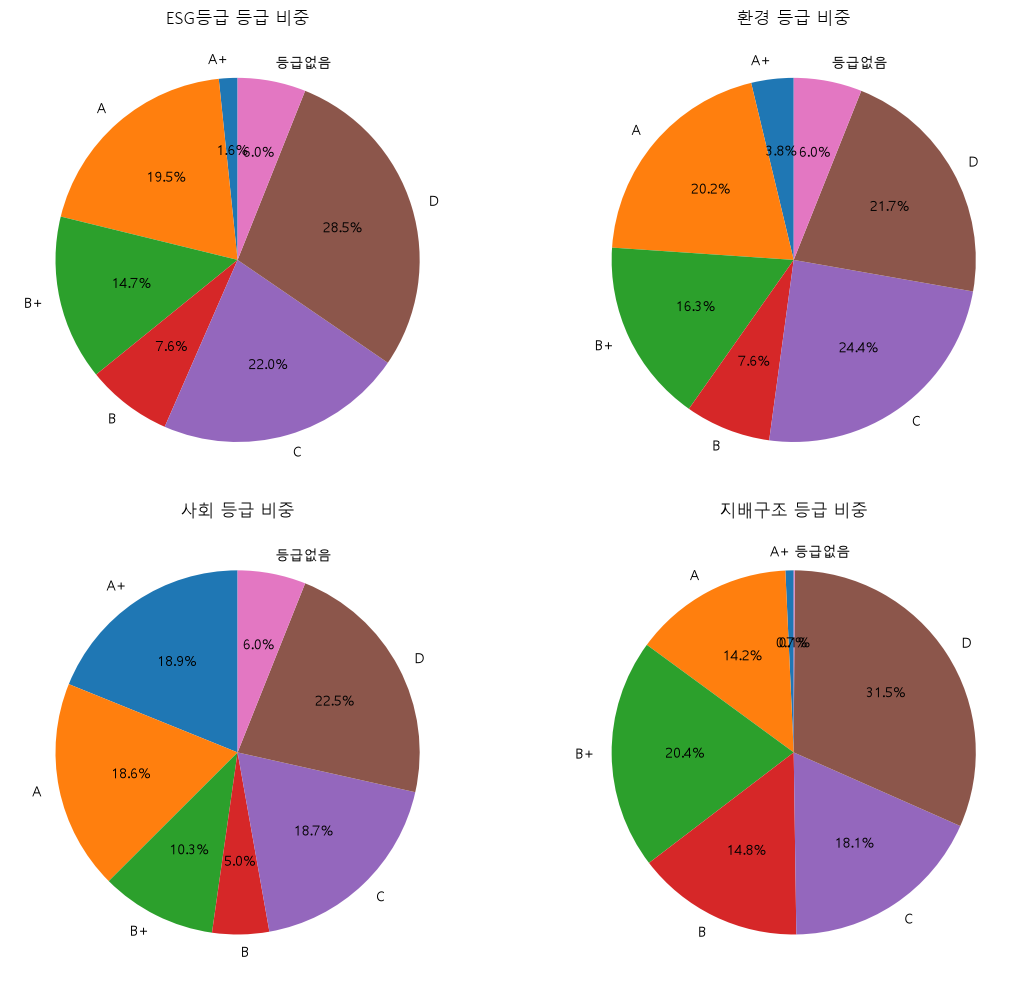

In [26]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

cols = ['ESG등급', '환경', '사회', '지배구조']

for ax, col in zip(axes.flat, cols):
    data = grade_count[col]

    ax.pie(
        data,
        labels=data.index,
        autopct='%1.1f%%',
        startangle=90
    )

    ax.set_title(f'{col} 등급 비중')

plt.tight_layout()
plt.show()